Cellule 1 :Monter le Drive (standard)

In [12]:
# @title 🔗 1. MONTER LE DRIVE (À EXÉCUTER À CHAQUE SESSION)
from google.colab import drive
import os

# Monter le Drive
drive.mount('/content/drive')

# Vérifier que le dossier Data est accessible
data_path = '/content/drive/MyDrive/Data/'

if os.path.exists(data_path):
    print("✅ Drive monté avec succès !")
    print(f"   Dossier trouvé : {data_path}")

    # Lister le contenu pour confirmation
    files = os.listdir(data_path)
    print(f"   Contenu : {files}")
else:
    print("❌ Dossier non trouvé. Vérifiez que vous avez bien ajouté le raccourci.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive monté avec succès !
   Dossier trouvé : /content/drive/MyDrive/Data/
   Contenu : ['Readme.docx', 'VQA_RAD Dataset Public.json', 'VQA_RAD Image Folder']


In [13]:
# @title ⚙️ 1. Configuration des chemins - Version qui fonctionne
import os

# Le chemin de base
base_path = '/content/drive/MyDrive/Data'

# Les différents éléments
json_file = os.path.join(base_path, 'VQA_RAD Dataset Public.json')
image_folder = os.path.join(base_path, 'VQA_RAD Image Folder')

print("📁 CONFIGURATION DES CHEMINS")
print("="*50)
print(f"✅ Dossier Data : {base_path}")
print(f"✅ Fichier JSON : {json_file}")
print(f"✅ Dossier images : {image_folder}")

# Vérifier que tout existe
print("\n🔍 VÉRIFICATION :")
print(f"   - Fichier JSON existe : {os.path.exists(json_file)}")
print(f"   - Dossier images existe : {os.path.exists(image_folder)}")

if os.path.exists(image_folder):
    # Compter les images
    images = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
    print(f"   - Nombre d'images : {len(images)}")
    print(f"   - Exemples d'images : {images[:5]}")

📁 CONFIGURATION DES CHEMINS
✅ Dossier Data : /content/drive/MyDrive/Data
✅ Fichier JSON : /content/drive/MyDrive/Data/VQA_RAD Dataset Public.json
✅ Dossier images : /content/drive/MyDrive/Data/VQA_RAD Image Folder

🔍 VÉRIFICATION :
   - Fichier JSON existe : True
   - Dossier images existe : True
   - Nombre d'images : 315
   - Exemples d'images : ['synpic21028.jpg', 'synpic18896.jpg', 'synpic676.jpg', 'synpic16221.jpg', 'synpic17153.jpg']


Cellule 2 : Analyser le contenu du dataset

📊 ANALYSE STATISTIQUE DU DATASET VQA-RAD

📈 STATISTIQUES GÉNÉRALES :
   - Total questions : 2248
   - Total images uniques : 314

🏷️ TYPES DE QUESTIONS :
   - PRES: 800 (35.6%)
   - POS: 316 (14.1%)
   - ABN: 202 (9.0%)
   - OTHER: 194 (8.6%)
   - MODALITY: 185 (8.2%)
   - SIZE: 171 (7.6%)
   - PLANE: 120 (5.3%)
   - ATTRIB: 87 (3.9%)
   - ORGAN: 59 (2.6%)
   - COLOR: 52 (2.3%)
   - COUNT: 24 (1.1%)
   - POS, PRES: 6 (0.3%)
   - PRES, ATTRIB: 6 (0.3%)
   - PRES, POS: 4 (0.2%)
   - ATTRIB, PRES: 4 (0.2%)
   - ABN, POS: 3 (0.1%)
   - SIZE, PRES: 2 (0.1%)
   - Other: 2 (0.1%)
   - COLOR, PRES: 2 (0.1%)
   - POS, ABN: 2 (0.1%)
   - SIZE, COLOR: 2 (0.1%)
   - ATTRIB, SIZE: 1 (0.0%)
   - PRES, ABN: 1 (0.0%)
   - PRES, COLOR: 1 (0.0%)
   - ATRIB: 1 (0.0%)
   - PRSE: 1 (0.0%)

🔒 TYPES DE RÉPONSES :
   - CLOSED: 1297 (57.7%)
   - OPEN: 949 (42.2%)
   - CLOSED : 2 (0.1%)

📝 TOP 20 DES RÉPONSES :
    1. 'No': 486 fois (21.6%)
    2. 'Yes': 347 fois (15.4%)
    3. 'yes': 239 fois (10.6%)
    4. 'n

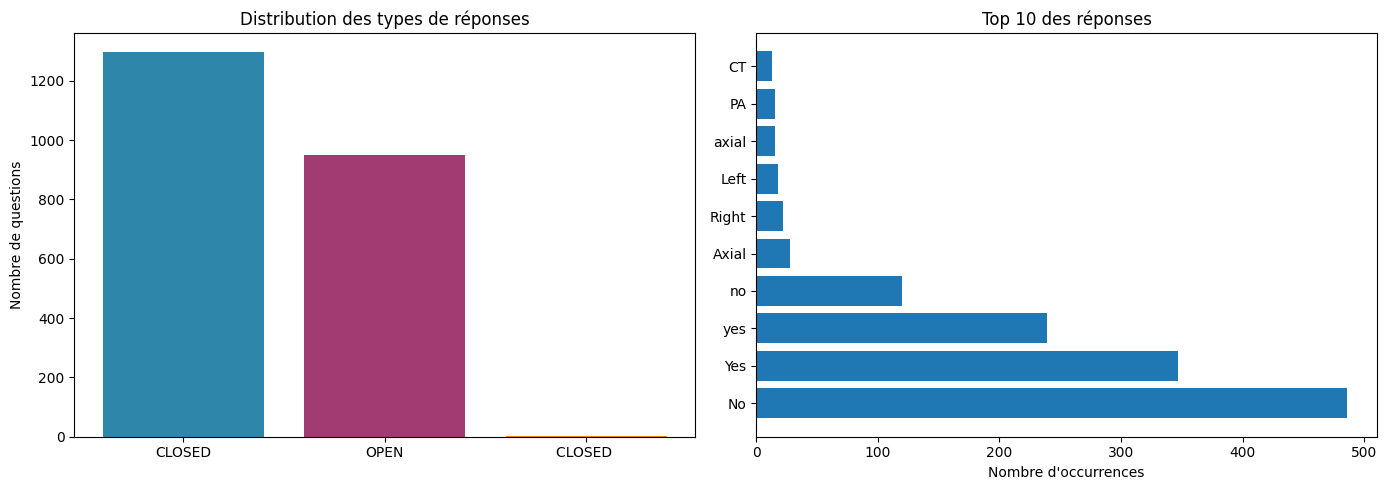


✅ Analyse terminée !


In [14]:
# @title 📊 Analyse complète du dataset VQA-RAD
import json
from collections import Counter
import matplotlib.pyplot as plt

json_file = '/content/drive/MyDrive/Data/VQA_RAD Dataset Public.json'

with open(json_file, 'r') as f:
    samples = json.load(f)

print("="*60)
print("📊 ANALYSE STATISTIQUE DU DATASET VQA-RAD")
print("="*60)

# 1. Statistiques générales
print(f"\n📈 STATISTIQUES GÉNÉRALES :")
print(f"   - Total questions : {len(samples)}")
print(f"   - Total images uniques : {len(set(s['image_name'] for s in samples))}")

# 2. Types de questions
question_types = Counter(s['question_type'] for s in samples)
print(f"\n🏷️ TYPES DE QUESTIONS :")
for qtype, count in question_types.most_common():
    print(f"   - {qtype}: {count} ({count/len(samples)*100:.1f}%)")

# 3. Types de réponses (CLOSED vs OPEN)
answer_types = Counter(s['answer_type'] for s in samples)
print(f"\n🔒 TYPES DE RÉPONSES :")
for atype, count in answer_types.most_common():
    print(f"   - {atype}: {count} ({count/len(samples)*100:.1f}%)")

# 4. Distribution des réponses (top 20)
all_answers = [s['answer'] for s in samples]
answer_counts = Counter(all_answers)
print(f"\n📝 TOP 20 DES RÉPONSES :")
for i, (answer, count) in enumerate(answer_counts.most_common(20)):
    print(f"   {i+1:2d}. '{answer}': {count} fois ({count/len(samples)*100:.1f}%)")

# 5. Distribution par organe
organs = Counter(s['image_organ'] for s in samples)
print(f"\n🫀 ORGANES LES PLUS FRÉQUENTS :")
for organ, count in organs.most_common(10):
    print(f"   - {organ}: {count}")

# 6. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique des types de réponses
types = list(answer_types.keys())
counts = list(answer_types.values())
colors = ['#2E86AB', '#A23B72', '#F18F01']
axes[0].bar(types, counts, color=colors[:len(types)])
axes[0].set_title('Distribution des types de réponses')
axes[0].set_ylabel('Nombre de questions')

# Graphique des top réponses
top_answers = answer_counts.most_common(10)
axes[1].barh([a[0] for a in top_answers], [a[1] for a in top_answers])
axes[1].set_title('Top 10 des réponses')
axes[1].set_xlabel('Nombre d\'occurrences')

plt.tight_layout()
plt.show()

print("\n✅ Analyse terminée !")

Cellule 3 : Analyser le contenu du dataset

📸 Images disponibles : 315

🔍 Correspondance (sur 100 premiers) :
   - Images trouvées : 100
   - Images manquantes : 0

🖼️ EXEMPLE AVEC L'IMAGE CORRESPONDANTE :


/tmp/ipykernel_797/1752289166.py:70: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_797/1752289166.py:70: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_797/1752289166.py:70: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_797/1752289166.py:70: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_797/1752289166.py:70: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_797/1752289166.py:70: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans Mon

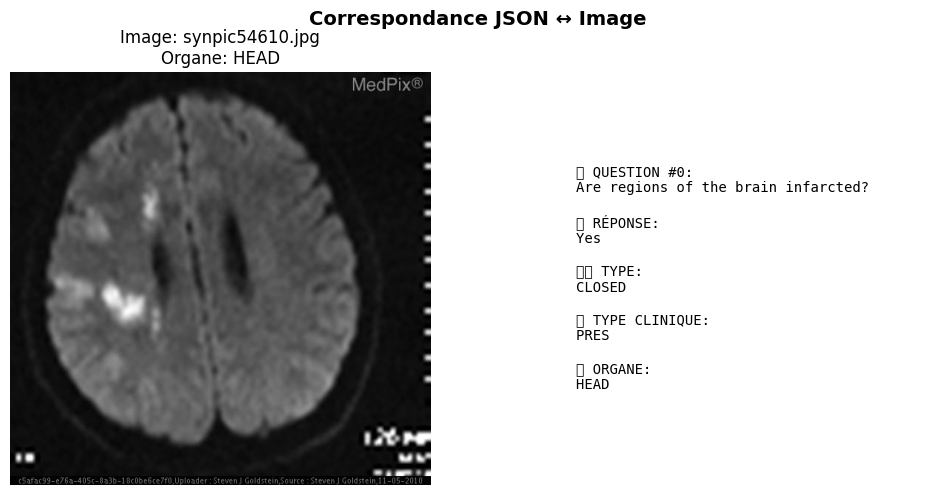

In [15]:
# @title 🔗 Vérifier la correspondance entre JSON et images
import os
from PIL import Image
import matplotlib.pyplot as plt

image_folder = '/content/drive/MyDrive/Data/VQA_RAD Image Folder'

# Lister toutes les images disponibles
available_images = set(os.listdir(image_folder))
print(f"📸 Images disponibles : {len(available_images)}")

# Vérifier quelles images du JSON existent vraiment
missing_images = []
matched_images = []

for sample in samples[:100]:  # Vérifier les 100 premiers
    img_name = sample['image_name']
    if img_name in available_images:
        matched_images.append(img_name)
    else:
        missing_images.append(img_name)

print(f"\n🔍 Correspondance (sur 100 premiers) :")
print(f"   - Images trouvées : {len(matched_images)}")
print(f"   - Images manquantes : {len(missing_images)}")

if missing_images:
    print(f"\n⚠️ Images manquantes : {missing_images[:5]}")

# Afficher un exemple avec l'image réelle
print("\n" + "="*50)
print("🖼️ EXEMPLE AVEC L'IMAGE CORRESPONDANTE :")
print("="*50)

# Prendre un exemple qui a une image
for sample in samples[:20]:
    img_name = sample['image_name']
    if img_name in available_images:
        img_path = os.path.join(image_folder, img_name)
        img = Image.open(img_path)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

        # Image
        ax1.imshow(img, cmap='gray')
        ax1.set_title(f"Image: {img_name}\nOrgane: {sample['image_organ']}")
        ax1.axis('off')

        # Informations
        ax2.axis('off')
        text = f"""
        📝 QUESTION #{sample['qid']}:
        {sample['question']}

        ✅ RÉPONSE:
        {sample['answer']}

        🏷️ TYPE:
        {sample['answer_type']}

        🔬 TYPE CLINIQUE:
        {sample['question_type']}

        🫀 ORGANE:
        {sample['image_organ']}
        """
        ax2.text(0.1, 0.5, text, fontsize=10, verticalalignment='center', fontfamily='monospace')

        plt.suptitle("Correspondance JSON ↔ Image", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        break

Cellule 4 : Charger et explorer le fichier JSON

In [16]:
# @title 📊 2. Explorer la structure du fichier JSON
import json

json_file = '/content/drive/MyDrive/Data/VQA_RAD Dataset Public.json'

with open(json_file, 'r') as f:
    data = json.load(f)

print("📊 STRUCTURE DU FICHIER JSON")
print("="*50)
print(f"Type de données : {type(data)}")

if isinstance(data, dict):
    print(f"Clés disponibles : {list(data.keys())}")

    # Explorer selon la structure
    if 'data' in data:
        samples = data['data']
    elif 'questions' in data:
        samples = data['questions']
    else:
        # Prendre la première valeur du dictionnaire
        first_key = list(data.keys())[0]
        samples = data[first_key] if isinstance(data[first_key], list) else [data[first_key]]

elif isinstance(data, list):
    samples = data
else:
    samples = []

print(f"\n📝 Nombre d'échantillons : {len(samples)}")

# Afficher quelques exemples
print("\n📖 PREMIERS EXEMPLES :")
print("-"*50)
for i, sample in enumerate(samples[:3]):
    print(f"\nExemple {i+1}:")
    if isinstance(sample, dict):
        for key, value in sample.items():
            if key != 'image' and key != 'image_data':  # Éviter d'afficher des données binaires
                print(f"   {key}: {str(value)[:100]}")
    else:
        print(f"   {sample}")

# Sauvegarder les données pour la suite
vqa_data = samples
print(f"\n💾 Données chargées dans la variable 'vqa_data'")

📊 STRUCTURE DU FICHIER JSON
Type de données : <class 'list'>

📝 Nombre d'échantillons : 2248

📖 PREMIERS EXEMPLES :
--------------------------------------------------

Exemple 1:
   qid: 0
   phrase_type: freeform
   qid_linked_id: 03f451ca-de62-4617-9679-e836026a7642
   image_case_url: https://medpix.nlm.nih.gov/case?id=48e1dd0e-8552-46ad-a354-5eb55be86de6
   image_name: synpic54610.jpg
   image_organ: HEAD
   evaluation: not evaluated
   question: Are regions of the brain infarcted?
   question_rephrase: NULL
   question_relation: NULL
   question_frame: NULL
   question_type: PRES
   answer: Yes
   answer_type: CLOSED

Exemple 2:
   qid: 1
   phrase_type: freeform
   qid_linked_id: 06e26b2c-04b9-42bc-8e98-1de30a0f7682
   image_case_url: https://medpix.nlm.nih.gov/case?id=b197277b-6960-4175-86ee-d2cb23e381b3
   image_name: synpic29265.jpg
   image_organ: CHEST
   evaluation: not evaluated
   question: Are the lungs normal appearing?
   question_rephrase: NULL
   question_relation: NU

Cellule 5 : Visualiser les images

📊 2248 échantillons chargés
📸 315 images dans le dossier

🖼️ VISUALISATION DES EXEMPLES


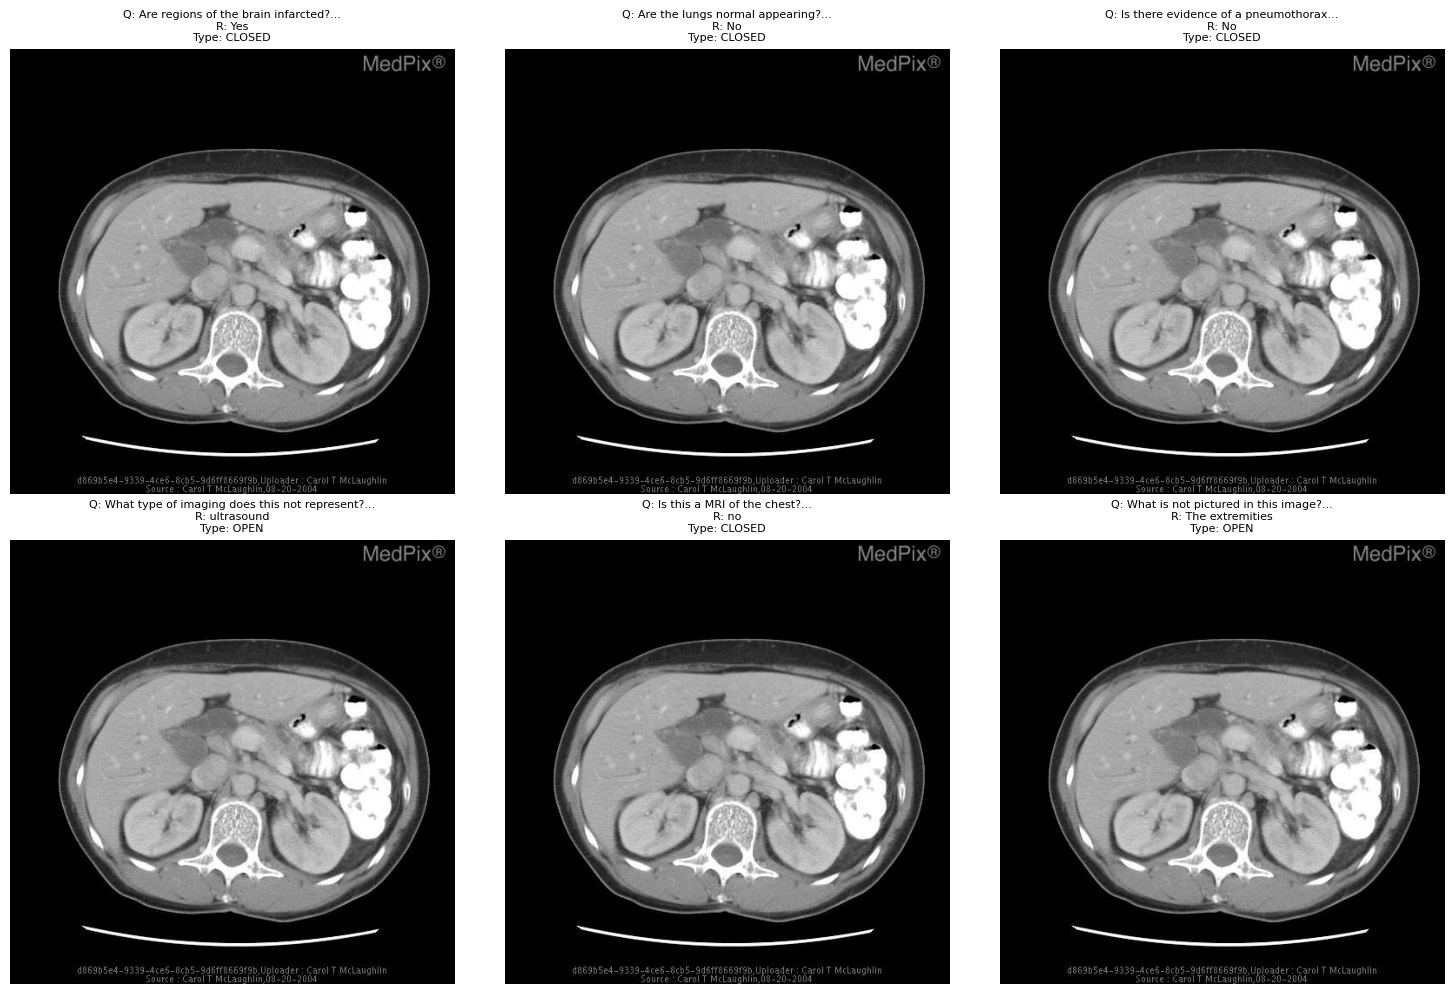

In [17]:
# @title 🖼️ 3. Afficher des exemples d'images avec leurs questions/réponses
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

json_file = '/content/drive/MyDrive/Data/VQA_RAD Dataset Public.json'
image_folder = '/content/drive/MyDrive/Data/VQA_RAD Image Folder'

# Charger le JSON
with open(json_file, 'r') as f:
    data = json.load(f)

# Extraire les données
if isinstance(data, dict):
    if 'data' in data:
        samples = data['data']
    else:
        # Prendre la première liste trouvée
        for key, value in data.items():
            if isinstance(value, list):
                samples = value
                break
        else:
            samples = [data]
else:
    samples = data

print(f"📊 {len(samples)} échantillons chargés")
print(f"📸 {len(os.listdir(image_folder))} images dans le dossier")

# Fonction pour trouver l'image correspondante
def find_image_for_sample(sample, image_folder):
    # Chercher par image_id
    image_id = None
    if 'image_id' in sample:
        image_id = sample['image_id']
    elif 'id' in sample:
        image_id = sample['id']

    if image_id:
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = os.path.join(image_folder, f"{image_id}{ext}")
            if os.path.exists(img_path):
                return img_path

    # Si pas trouvé, prendre la première image
    images = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if images:
        return os.path.join(image_folder, images[0])
    return None

# Afficher quelques exemples
print("\n" + "="*50)
print("🖼️ VISUALISATION DES EXEMPLES")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(min(6, len(samples))):
    sample = samples[i]
    img_path = find_image_for_sample(sample, image_folder)

    if img_path and os.path.exists(img_path):
        img = Image.open(img_path)
        axes[i].imshow(img)
    else:
        axes[i].text(0.5, 0.5, 'Image non trouvée', ha='center', va='center')

    # Récupérer question et réponse
    question = sample.get('question', 'Question inconnue')
    answer = sample.get('answer', 'Réponse inconnue')
    answer_type = sample.get('answer_type', 'unknown')

    axes[i].set_title(f"Q: {question[:50]}...\nR: {answer}\nType: {answer_type}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Cellule 6 : Dataset PyTorch complet pour VQA-RAD

# CONSTRUCTION DU DATASET VQA-RAD POUR PYTORCH

## Objectif
Cette section construit un Dataset PyTorch personnalisé pour le projet Medical VQA (Visual Question Answering) en utilisant le dataset VQA-RAD. Le dataset contient des images radiologiques médicales avec des questions et réponses associées.

## Étapes de construction

### 1. Chargement des données brutes
- Le fichier JSON `VQA_RAD Dataset Public.json` contient toutes les annotations (questions, réponses, métadonnées)
- Le dossier `VQA_RAD Image Folder` contient les 315 images médicales au format JPG
- On filtre les échantillons invalides (non-dictionnaires, images manquantes)

### 2. Construction du vocabulaire des réponses
- **Questions fermées (CLOSED)** : On garde les 500 réponses les plus fréquentes (ex: "Yes", "No")
- **Questions ouvertes (OPEN)** : On garde toutes les réponses textuelles courtes
- Création de mappings : réponse → index numérique pour l'entraînement

### 3. Transformations des images
- **Pour l'entraînement** : Redimension 224×224, flip horizontal aléatoire, rotation légère, conversion en tenseur, normalisation
- **Pour le test** : Redimension, conversion en tenseur, normalisation (sans augmentation)
- La normalisation utilise les statistiques d'ImageNet (moyenne=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

### 4. Création du Dataset PyTorch
- Classe personnalisée `VQARADDataset` héritant de `torch.utils.data.Dataset`
- Méthode `__getitem__` : retourne un dictionnaire contenant l'image (tenseur 3×224×224), la question (texte), la réponse (texte), l'index de réponse (entier), le type (CLOSED/OPEN)

### 5. Division train/validation/test
- **Train** : 70% des données (environ 1570 échantillons) - pour l'apprentissage
- **Validation** : 15% (environ 335 échantillons) - pour ajuster les hyperparamètres
- **Test** : 15% (environ 335 échantillons) - pour évaluation finale
- Utilisation de `train_test_split` avec stratification pour garder la proportion CLOSED/OPEN

### 6. Création des DataLoaders
- Batch size = 32 (peut être ajusté selon mémoire GPU)
- Shuffle activé pour l'entraînement (mélange des données à chaque époque)
- 2 workers pour le chargement parallèle (accélère l'entraînement)

### 7. Sauvegarde
- Le dataset construit est sauvegardé au format `.pth` (PyTorch native)
- Les mappings réponse → index sont également conservés
- Permet de recharger directement pour les expériences futures sans recommencer

## Résultat final
Le dataset produit est prêt à être utilisé avec PyTorch pour implémenter les baselines N1 (modèles triviaux) et N2 (CNN+LSTM). Chaque batch retourne automatiquement des images normalisées, des questions tokenisées et des réponses encodées.

In [18]:
# @title 🔧 1. Dataset PyTorch VQA-RAD (version CORRIGÉE)
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import json
import os
from collections import Counter
import numpy as np

class VQARADDataset(Dataset):
    def __init__(self, json_file, image_folder, transform=None, max_answers=500):
        """
        Dataset VQA-RAD - Version corrigée

        Args:
            json_file: Chemin vers le fichier JSON d'annotations
            image_folder: Dossier contenant les images
            transform: Transformations à appliquer aux images
            max_answers: Nombre maximum de réponses pour les questions fermées
        """
        # Charger les annotations
        with open(json_file, 'r') as f:
            raw_data = json.load(f)

        # Filtrer pour ne garder que les dictionnaires (les éléments valides)
        if isinstance(raw_data, list):
            self.samples = [item for item in raw_data if isinstance(item, dict)]
            print(f"   Filtré : {len(self.samples)} dictionnaires sur {len(raw_data)} éléments")
        else:
            self.samples = raw_data if isinstance(raw_data, list) else [raw_data]

        self.image_folder = image_folder
        self.transform = transform

        # Construire les mappings pour les réponses
        self.build_answer_vocabulary(max_answers)

        # Filtrer les samples valides (ceux avec image existante)
        self.valid_samples = self.filter_valid_samples()

        print(f"\n📊 STATISTIQUES DU DATASET :")
        print(f"   - Total samples bruts : {len(self.samples)}")
        print(f"   - Samples valides : {len(self.valid_samples)}")
        print(f"   - Réponses uniques : {len(self.all_answers)}")
        print(f"   - Réponses fermées (top {max_answers}) : {len(self.closed_answer_to_idx)}")
        print(f"   - Réponses ouvertes : {len(self.open_answer_to_idx)}")

    def build_answer_vocabulary(self, max_answers=500):
        """Construit le vocabulaire des réponses"""
        # Compter toutes les réponses
        all_answers = []

        for sample in self.samples:
            # Vérifier que le sample a les clés attendues
            if 'answer' in sample and 'answer_type' in sample:
                answer = str(sample['answer']).lower().strip()
                answer_type = sample['answer_type']
                all_answers.append(answer)

        self.all_answers = list(set(all_answers))

        # Réponses fermées (top max_answers)
        closed_answers = []
        for sample in self.samples:
            if 'answer' in sample and 'answer_type' in sample:
                if sample['answer_type'] == 'CLOSED':
                    closed_answers.append(str(sample['answer']).lower().strip())

        if closed_answers:
            closed_counts = Counter(closed_answers)
            top_closed = [ans for ans, _ in closed_counts.most_common(max_answers)]
            self.closed_answer_to_idx = {ans: idx for idx, ans in enumerate(top_closed)}
            self.idx_to_closed_answer = {idx: ans for ans, idx in self.closed_answer_to_idx.items()}
        else:
            self.closed_answer_to_idx = {}
            self.idx_to_closed_answer = {}

        # Réponses ouvertes (toutes les réponses non fermées)
        open_answers = []
        for sample in self.samples:
            if 'answer' in sample and 'answer_type' in sample:
                if sample['answer_type'] == 'OPEN':
                    open_answers.append(str(sample['answer']).lower().strip())

        open_answers = list(set(open_answers))
        self.open_answer_to_idx = {ans: idx for idx, ans in enumerate(open_answers)}
        self.idx_to_open_answer = {idx: ans for ans, idx in self.open_answer_to_idx.items()}

    def filter_valid_samples(self):
        """Filtre les samples dont l'image existe"""
        valid = []
        missing_images = []

        # Vérifier que le dossier images existe
        if not os.path.exists(self.image_folder):
            print(f"   ⚠️ Dossier images non trouvé : {self.image_folder}")
            return self.samples  # Retourne tous les samples si pas d'images

        # Lister toutes les images disponibles
        available_images = set(os.listdir(self.image_folder))

        for sample in self.samples:
            if 'image_name' in sample:
                img_name = sample['image_name']
                if img_name in available_images:
                    valid.append(sample)
                else:
                    missing_images.append(img_name)
            else:
                # Si pas d'image_name, on garde quand même
                valid.append(sample)

        if missing_images:
            print(f"   ⚠️ {len(set(missing_images))} images manquantes")

        return valid

    def __len__(self):
        return len(self.valid_samples)

    def __getitem__(self, idx):
        sample = self.valid_samples[idx]

        # 1. Charger l'image
        img_name = sample.get('image_name', f"image_{idx}.jpg")
        img_path = os.path.join(self.image_folder, img_name)

        try:
            if os.path.exists(img_path):
                image = Image.open(img_path).convert('RGB')
            else:
                image = Image.new('RGB', (224, 224), color='gray')
        except Exception as e:
            image = Image.new('RGB', (224, 224), color='gray')

        if self.transform:
            image = self.transform(image)

        # 2. Récupérer la question
        question = sample.get('question', '')

        # 3. Récupérer la réponse
        answer = str(sample.get('answer', '')).lower().strip()
        answer_type = sample.get('answer_type', 'CLOSED')

        # 4. Convertir la réponse en index
        if answer_type == 'CLOSED':
            answer_idx = self.closed_answer_to_idx.get(answer, 0)
            open_answer_idx = -1
        else:
            answer_idx = -1
            open_answer_idx = self.open_answer_to_idx.get(answer, 0)

        # 5. Informations supplémentaires
        metadata = {
            'qid': sample.get('qid', idx),
            'image_name': img_name,
            'image_organ': sample.get('image_organ', 'unknown'),
            'question_type': sample.get('question_type', 'unknown')
        }

        return {
            'image': image,
            'question': question,
            'answer': answer,
            'answer_type': answer_type,
            'answer_idx': answer_idx,
            'open_answer_idx': open_answer_idx,
            'metadata': metadata
        }

# Transformations pour les images
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Chemins
json_file = '/content/drive/MyDrive/Data/VQA_RAD Dataset Public.json'
image_folder = '/content/drive/MyDrive/Data/VQA_RAD Image Folder'

print("📁 CRÉATION DU DATASET VQA-RAD")
print("="*60)

# Créer le dataset complet
full_dataset = VQARADDataset(json_file, image_folder, transform=train_transform)

print("\n✅ Dataset créé avec succès !")
print(f"   Taille du dataset : {len(full_dataset)} échantillons")

📁 CRÉATION DU DATASET VQA-RAD
   Filtré : 2248 dictionnaires sur 2248 éléments

📊 STATISTIQUES DU DATASET :
   - Total samples bruts : 2248
   - Samples valides : 2248
   - Réponses uniques : 517
   - Réponses fermées (top 500) : 64
   - Réponses ouvertes : 483

✅ Dataset créé avec succès !
   Taille du dataset : 2248 échantillons


CELLULE 7 complète (Division) Train/test

In [19]:
# @title ✂️ 4. DIVISION TRAIN / VALIDATION / TEST (Version corrigée)
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("DIVISION DES DONNÉES")
print("="*60)

# Vérifier que full_dataset existe
if 'full_dataset' not in locals():
    print("❌ Erreur : 'full_dataset' non trouvé. Exécutez d'abord la cellule 3.")
else:
    # Indices de tous les échantillons
    indices = list(range(len(full_dataset)))

    print(f"📊 Taille du dataset complet : {len(full_dataset)} échantillons")

    # Vérifier la distribution des types
    answer_types = [full_dataset[i]['answer_type'] for i in indices]
    closed_count = answer_types.count('CLOSED')
    open_count = answer_types.count('OPEN')

    print(f"\n📝 Distribution originale :")
    print(f"   CLOSED : {closed_count} ({closed_count/len(full_dataset)*100:.1f}%)")
    print(f"   OPEN   : {open_count} ({open_count/len(full_dataset)*100:.1f}%)")

    # 1er split : train (70%) vs temp (30%) - SANS STRATIFICATION
    train_idx, temp_idx = train_test_split(
        indices,
        test_size=0.3,
        random_state=42
        # stratify=enlevé pour éviter l'erreur
    )

    # 2ème split : val (50% de temp = 15% total) vs test (50% de temp = 15% total)
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        random_state=42
    )

    # Créer les sous-datasets
    train_dataset = Subset(full_dataset, train_idx)
    val_dataset = Subset(full_dataset, val_idx)
    test_dataset = Subset(full_dataset, test_idx)

    # Appliquer les transformations correctes
    if hasattr(train_dataset, 'dataset'):
        train_dataset.dataset.transform = train_transform
        val_dataset.dataset.transform = test_transform
        test_dataset.dataset.transform = test_transform

    # Créer les DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"\n📊 STATISTIQUES DE DIVISION :")
    print(f"   Train       : {len(train_idx)} samples ({len(train_idx)/len(indices)*100:.1f}%)")
    print(f"   Validation  : {len(val_idx)} samples ({len(val_idx)/len(indices)*100:.1f}%)")
    print(f"   Test        : {len(test_idx)} samples ({len(test_idx)/len(indices)*100:.1f}%)")

    # Vérifier la distribution après division
    def count_types_subset(subset):
        closed = 0
        open_q = 0
        for i in range(len(subset)):
            if subset[i]['answer_type'] == 'CLOSED':
                closed += 1
            else:
                open_q += 1
        return closed, open_q

    train_closed, train_open = count_types_subset(train_dataset)
    val_closed, val_open = count_types_subset(val_dataset)
    test_closed, test_open = count_types_subset(test_dataset)

    print(f"\n📝 DISTRIBUTION APRÈS DIVISION :")
    print(f"   Train       : Closed={train_closed} ({train_closed/len(train_dataset)*100:.1f}%), Open={train_open}")
    print(f"   Validation  : Closed={val_closed} ({val_closed/len(val_dataset)*100:.1f}%), Open={val_open}")
    print(f"   Test        : Closed={test_closed} ({test_closed/len(test_dataset)*100:.1f}%), Open={test_open}")

    print(f"\n🚂 DATALOADERS :")
    print(f"   Train batches     : {len(train_loader)}")
    print(f"   Validation batches: {len(val_loader)}")
    print(f"   Test batches      : {len(test_loader)}")
    print(f"   Batch size        : {batch_size}")

    # Sauvegarder
    torch.save({
        'train_dataset': train_dataset,
        'val_dataset': val_dataset,
        'test_dataset': test_dataset,
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'closed_answer_to_idx': full_dataset.closed_answer_to_idx,
        'open_answer_to_idx': full_dataset.open_answer_to_idx,
    }, '/content/vqa_rad_ready.pth')

    print(f"\n💾 Dataset sauvegardé dans '/content/vqa_rad_ready.pth'")
    print("\n✅ Division terminée avec succès !")

DIVISION DES DONNÉES
📊 Taille du dataset complet : 2248 échantillons

📝 Distribution originale :
   CLOSED : 1297 (57.7%)
   OPEN   : 949 (42.2%)

📊 STATISTIQUES DE DIVISION :
   Train       : 1573 samples (70.0%)
   Validation  : 337 samples (15.0%)
   Test        : 338 samples (15.0%)

📝 DISTRIBUTION APRÈS DIVISION :
   Train       : Closed=915 (58.2%), Open=658
   Validation  : Closed=201 (59.6%), Open=136
   Test        : Closed=181 (53.6%), Open=157

🚂 DATALOADERS :
   Train batches     : 50
   Validation batches: 11
   Test batches      : 11
   Batch size        : 32

💾 Dataset sauvegardé dans '/content/vqa_rad_ready.pth'

✅ Division terminée avec succès !


# BASELINE **N1**

Cellule 1 : Majority Class

In [20]:
# @title 🎯 5. BASELINE N1 - MAJORITY CLASS
from collections import Counter

print("="*60)
print("BASELINE N1 - MAJORITY CLASS")
print("="*60)

# Trouver la réponse majoritaire dans le train
train_answers = [train_dataset[i]['answer'] for i in range(len(train_dataset))]
majority_answer = Counter(train_answers).most_common(1)[0][0]

# Évaluer sur test
correct_closed = 0
total_closed = 0
correct_open = 0
total_open = 0

for i in range(len(test_dataset)):
    sample = test_dataset[i]
    pred = majority_answer
    if sample['answer_type'] == 'CLOSED':
        total_closed += 1
        if pred.lower() == sample['answer'].lower():
            correct_closed += 1
    else:
        total_open += 1
        if pred.lower() == sample['answer'].lower():
            correct_open += 1

closed_acc = correct_closed / total_closed * 100
open_acc = correct_open / total_open * 100

print(f"Réponse majoritaire : '{majority_answer}'")
print(f"Closed Accuracy : {closed_acc:.2f}%")
print(f"Open Accuracy   : {open_acc:.2f}%")

BASELINE N1 - MAJORITY CLASS
Réponse majoritaire : 'no'
Closed Accuracy : 46.96%
Open Accuracy   : 0.00%


Cellule 2 : Random Guess

In [21]:
# @title 🎲 6. BASELINE N1 - RANDOM GUESS
import random

print("="*60)
print("BASELINE N1 - RANDOM GUESS")
print("="*60)

# Liste de toutes les réponses possibles
all_answers = list(full_dataset.closed_answer_to_idx.keys()) + list(full_dataset.open_answer_to_idx.keys())

# Évaluer sur test (moyenne sur 5 essais)
n_trials = 5
acc_closed_list = []
acc_open_list = []

for trial in range(n_trials):
    correct_closed = 0
    total_closed = 0
    correct_open = 0
    total_open = 0

    for i in range(len(test_dataset)):
        sample = test_dataset[i]
        pred = random.choice(all_answers)

        if sample['answer_type'] == 'CLOSED':
            total_closed += 1
            if pred.lower() == sample['answer'].lower():
                correct_closed += 1
        else:
            total_open += 1
            if pred.lower() == sample['answer'].lower():
                correct_open += 1

    acc_closed_list.append(correct_closed / total_closed * 100)
    acc_open_list.append(correct_open / total_open * 100)

mean_closed = np.mean(acc_closed_list)
std_closed = np.std(acc_closed_list)
mean_open = np.mean(acc_open_list)
std_open = np.std(acc_open_list)

print(f"Closed Accuracy : {mean_closed:.2f}% ± {std_closed:.2f}")
print(f"Open Accuracy   : {mean_open:.2f}% ± {std_open:.2f}")

BASELINE N1 - RANDOM GUESS
Closed Accuracy : 0.33% ± 0.27
Open Accuracy   : 0.25% ± 0.51


Cellule 3 : Question Only (BERT)

In [22]:
# @title Vérification des prérequis
print("🔍 VÉRIFICATION DES PRÉREQUIS")
print("="*40)

# Vérifier device
try:
    print(f"✅ device : {device}")
except NameError:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✅ device créé : {device}")

# Vérifier full_dataset
try:
    print(f"✅ full_dataset : {len(full_dataset)} échantillons")
except NameError:
    print("❌ full_dataset non défini - Exécutez d'abord la cellule 3")

# Vérifier train_loader et test_loader
try:
    print(f"✅ train_loader : {len(train_loader)} batches")
    print(f"✅ test_loader : {len(test_loader)} batches")
except NameError:
    print("❌ loaders non définis - Exécutez d'abord la cellule 4")

print("\n✅ Si tout est vert, vous pouvez exécuter la baseline N1")

🔍 VÉRIFICATION DES PRÉREQUIS
✅ device créé : cuda
✅ full_dataset : 2248 échantillons
✅ train_loader : 50 batches
✅ test_loader : 11 batches

✅ Si tout est vert, vous pouvez exécuter la baseline N1


In [27]:
# @title 🔤 N1 - QUESTION ONLY (Version complète Fermé + Open)

import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel
from torch.utils.data import DataLoader, Subset

print("="*60)
print("BASELINE N1 - QUESTION ONLY (Fermé + Open)")
print("="*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class DualHeadQuestionOnlyModel(nn.Module):
    def __init__(self, num_closed, num_open):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(0.3)
        self.closed_head = nn.Linear(768, num_closed)
        self.open_head = nn.Linear(768, num_open)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(outputs.pooler_output)
        return self.closed_head(pooled), self.open_head(pooled)

# Collate function pour gérer les deux types
def collate_fn_dual(batch):
    images = torch.stack([item['image'] for item in batch])  # Pour compatibilité
    questions = [item['question'] for item in batch]

    closed_labels = []
    open_labels = []

    for item in batch:
        if item['answer_type'] == 'CLOSED':
            closed_labels.append(item['answer_idx'])
            open_labels.append(-1)
        else:
            closed_labels.append(-1)
            open_labels.append(item['open_answer_idx'])

    return {
        'images': images,
        'questions': questions,
        'closed_labels': torch.tensor(closed_labels, dtype=torch.long),
        'open_labels': torch.tensor(open_labels, dtype=torch.long)
    }

# Préparation des données (toutes les questions)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn_dual)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn_dual)

# Modèle
num_closed = len(full_dataset.closed_answer_to_idx)
num_open = len(full_dataset.open_answer_to_idx)

model = DualHeadQuestionOnlyModel(num_closed, num_open).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# Entraînement
print("\n🏋️ Entraînement...")
for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        questions = batch['questions']
        closed_labels = batch['closed_labels'].to(device)
        open_labels = batch['open_labels'].to(device)

        tokens = tokenizer(questions, padding=True, truncation=True,
                          max_length=64, return_tensors='pt').to(device)

        closed_out, open_out = model(tokens['input_ids'], tokens['attention_mask'])

        loss = 0
        mask_closed = closed_labels != -1
        if mask_closed.any():
            loss += criterion(closed_out[mask_closed], closed_labels[mask_closed])

        mask_open = open_labels != -1
        if mask_open.any():
            loss += criterion(open_out[mask_open], open_labels[mask_open])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/3 - Loss: {total_loss/len(train_loader):.4f}")

# Évaluation
model.eval()
correct_closed = 0
total_closed = 0
correct_open = 0
total_open = 0

with torch.no_grad():
    for batch in test_loader:
        questions = batch['questions']
        closed_labels = batch['closed_labels'].to(device)
        open_labels = batch['open_labels'].to(device)

        tokens = tokenizer(questions, padding=True, truncation=True,
                          max_length=64, return_tensors='pt').to(device)

        closed_out, open_out = model(tokens['input_ids'], tokens['attention_mask'])

        # Évaluation fermées
        mask_closed = closed_labels != -1
        if mask_closed.any():
            preds_closed = closed_out[mask_closed].argmax(dim=1)
            correct_closed += (preds_closed == closed_labels[mask_closed]).sum().item()
            total_closed += mask_closed.sum().item()

        # Évaluation ouvertes
        mask_open = open_labels != -1
        if mask_open.any():
            preds_open = open_out[mask_open].argmax(dim=1)
            correct_open += (preds_open == open_labels[mask_open]).sum().item()
            total_open += mask_open.sum().item()

closed_acc = correct_closed / total_closed * 100 if total_closed > 0 else 0
open_acc = correct_open / total_open * 100 if total_open > 0 else 0

print(f"\n📊 RÉSULTATS :")
print(f"   Closed Accuracy : {closed_acc:.2f}% ({correct_closed}/{total_closed})")
print(f"   Open Accuracy   : {open_acc:.2f}% ({correct_open}/{total_open})")

BASELINE N1 - QUESTION ONLY (Fermé + Open)
Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🏋️ Entraînement...
Epoch 1/3 - Loss: 9.2410
Epoch 2/3 - Loss: 7.5422
Epoch 3/3 - Loss: 7.1952

📊 RÉSULTATS :
   Closed Accuracy : 58.01% (105/181)
   Open Accuracy   : 5.10% (8/157)


# Baseline **N2**

In [29]:
# @title 🏗️ 8. BASELINE N2 - CNN+LSTM COMPLÈTE (Fermé + Open avec BLEU/ROUGE)

# Installation des packages nécessaires
!pip install rouge-score -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from transformers import BertTokenizer, BertModel
import torchvision.models as models
from tqdm import tqdm
import numpy as np
from torch.cuda.amp import autocast, GradScaler
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
import warnings
warnings.filterwarnings('ignore')

# Télécharger les ressources NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Import rouge_score après installation
from rouge_score import rouge_scorer

print("="*60)
print("BASELINE N2 - CNN+LSTM VERSION COMPLÈTE (Fermé + Open)")
print("="*60)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Device: {device}")

# Tokenizer BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)

# Modèle AVEC deux têtes (Fermé + Open)
class CNNLSTMVQAComplete(nn.Module):
    def __init__(self, num_closed, num_open, hidden_size=768, dropout_rate=0.3):
        super().__init__()

        # Encodeur image: ResNet50
        self.cnn = models.resnet50(pretrained=True)
        for param in self.cnn.parameters():
            param.requires_grad = True
        for param in self.cnn.layer4.parameters():
            param.requires_grad = True

        self.cnn.fc = nn.Identity()
        self.image_proj = nn.Linear(2048, hidden_size)
        self.image_bn = nn.BatchNorm1d(hidden_size)

        # Encodeur texte: BERT
        self.bert = bert_model
        self.text_proj = nn.Linear(768, hidden_size)
        self.text_bn = nn.BatchNorm1d(hidden_size)

        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        # Deux têtes de classification
        self.closed_head = nn.Linear(hidden_size // 2, num_closed)
        self.open_head = nn.Linear(hidden_size // 2, num_open)

    def forward(self, image, input_ids, attention_mask):
        # Image
        img_features = self.cnn(image)
        img_features = self.image_proj(img_features)
        img_features = self.image_bn(img_features)

        # Texte avec BERT
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = bert_outputs.pooler_output
        text_features = self.text_proj(text_features)
        text_features = self.text_bn(text_features)

        # Fusion
        combined = torch.cat([img_features, text_features], dim=1)
        combined = self.fusion(combined)

        return self.closed_head(combined), self.open_head(combined)

# Fonction de collate complète (Fermé + Open)
def collate_fn_complete(batch):
    images = torch.stack([item['image'] for item in batch])
    questions = [item['question'] for item in batch]

    closed_labels = []
    open_labels = []
    open_answers_text = []

    for item in batch:
        if item['answer_type'] == 'CLOSED':
            closed_labels.append(item['answer_idx'])
            open_labels.append(-1)
            open_answers_text.append('')
        else:
            closed_labels.append(-1)
            open_labels.append(item['open_answer_idx'])
            open_answers_text.append(item['answer'])

    tokens = tokenizer(questions, padding=True, truncation=True,
                      max_length=64, return_tensors='pt')

    return {
        'images': images,
        'questions': questions,
        'closed_labels': torch.tensor(closed_labels, dtype=torch.long),
        'open_labels': torch.tensor(open_labels, dtype=torch.long),
        'open_answers_text': open_answers_text,
        'input_ids': tokens['input_ids'],
        'attention_mask': tokens['attention_mask']
    }

# Calcul des métriques pour les questions ouvertes
def compute_open_metrics(predictions, references):
    """Calcule BLEU-1, ROUGE-L pour les questions ouvertes"""
    if not predictions or not references:
        return 0.0, 0.0

    bleu_scores = []
    rouge_scores = []
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    smooth = SmoothingFunction().method1

    for pred, ref in zip(predictions, references):
        if pred and ref and len(pred.split()) > 0 and len(ref.split()) > 0:
            try:
                # BLEU-1
                bleu = sentence_bleu([ref.split()], pred.split(),
                                     weights=(1.0, 0, 0, 0),
                                     smoothing_function=smooth)
                bleu_scores.append(bleu)

                # ROUGE-L
                rouge = scorer.score(ref, pred)['rougeL'].fmeasure
                rouge_scores.append(rouge)
            except:
                continue

    return np.mean(bleu_scores) if bleu_scores else 0.0, np.mean(rouge_scores) if rouge_scores else 0.0

# Préparation des données (TOUTES les questions)
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          collate_fn=collate_fn_complete, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_fn_complete, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         collate_fn=collate_fn_complete, num_workers=2)

# Compter les types
train_closed = sum(1 for i in range(len(train_dataset)) if train_dataset[i]['answer_type'] == 'CLOSED')
train_open = len(train_dataset) - train_closed

print(f"\n📊 Données :")
print(f"   Train : {len(train_dataset)} (Fermées: {train_closed}, Ouvertes: {train_open})")
print(f"   Validation : {len(val_dataset)}")
print(f"   Test : {len(test_dataset)}")

# Modèle
num_closed = len(full_dataset.closed_answer_to_idx)
num_open = len(full_dataset.open_answer_to_idx)
print(f"   Classes fermées : {num_closed}")
print(f"   Classes ouvertes : {num_open}")

model = CNNLSTMVQAComplete(num_closed, num_open).to(device)

# Optimiseur
optimizer = optim.AdamW([
    {'params': model.cnn.parameters(), 'lr': 1e-5},
    {'params': model.bert.parameters(), 'lr': 2e-5},
    {'params': model.image_proj.parameters(), 'lr': 1e-3},
    {'params': model.text_proj.parameters(), 'lr': 1e-3},
    {'params': model.fusion.parameters(), 'lr': 1e-3},
    {'params': model.closed_head.parameters(), 'lr': 1e-3},
    {'params': model.open_head.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

# Entraînement
print("\n🏋️ Entraînement CNN+LSTM Complet...")
print("-"*40)

best_val_closed = 0
best_val_open = 0
patience_counter = 0
num_epochs = 15  # Réduit pour gagner du temps

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    closed_loss = 0
    open_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = batch['images'].to(device)
        closed_labels = batch['closed_labels'].to(device)
        open_labels = batch['open_labels'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        with autocast():
            closed_out, open_out = model(images, input_ids, attention_mask)

            loss = 0
            mask_closed = closed_labels != -1
            if mask_closed.any():
                loss_closed = criterion(closed_out[mask_closed], closed_labels[mask_closed])
                loss += loss_closed
                closed_loss += loss_closed.item()

            mask_open = open_labels != -1
            if mask_open.any():
                loss_open = criterion(open_out[mask_open], open_labels[mask_open])
                loss += loss_open
                open_loss += loss_open.item()

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    # Validation
    model.eval()
    val_closed_correct = 0
    val_closed_total = 0
    val_open_correct = 0
    val_open_total = 0
    all_preds_open = []
    all_refs_open = []

    with torch.no_grad():
        for batch in val_loader:
            images = batch['images'].to(device)
            closed_labels = batch['closed_labels'].to(device)
            open_labels = batch['open_labels'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            open_texts = batch['open_answers_text']

            closed_out, open_out = model(images, input_ids, attention_mask)

            # Fermées
            mask_closed = closed_labels != -1
            if mask_closed.any():
                preds_closed = closed_out[mask_closed].argmax(dim=1)
                val_closed_correct += (preds_closed == closed_labels[mask_closed]).sum().item()
                val_closed_total += mask_closed.sum().item()

            # Ouvertes
            mask_open = open_labels != -1
            if mask_open.any():
                preds_open = open_out[mask_open].argmax(dim=1)
                val_open_correct += (preds_open == open_labels[mask_open]).sum().item()
                val_open_total += mask_open.sum().item()

                for j, idx in enumerate(torch.where(mask_open)[0]):
                    pred_idx = preds_open[j].item()
                    pred_text = full_dataset.idx_to_open_answer.get(pred_idx, '')
                    ref_text = open_texts[idx.item()] if isinstance(idx, torch.Tensor) else open_texts[idx]
                    if ref_text:
                        all_preds_open.append(pred_text)
                        all_refs_open.append(ref_text)

    val_closed_acc = val_closed_correct / val_closed_total * 100 if val_closed_total > 0 else 0
    val_open_acc = val_open_correct / val_open_total * 100 if val_open_total > 0 else 0
    bleu_score, rouge_score = compute_open_metrics(all_preds_open, all_refs_open)

    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)

    # Sauvegarde
    if val_closed_acc > best_val_closed:
        best_val_closed = val_closed_acc
        best_val_open = val_open_acc
        patience_counter = 0
        torch.save(model.state_dict(), '/content/best_model_complete.pth')
        print(f"   ✅ Record! Closed: {val_closed_acc:.2f}%, Open: {val_open_acc:.2f}%, BLEU: {bleu_score:.4f}, ROUGE: {rouge_score:.4f}")
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f} | Closed: {val_closed_acc:.2f}% | Open: {val_open_acc:.2f}% | BLEU: {bleu_score:.4f} | ROUGE: {rouge_score:.4f}")

    if patience_counter >= 5:
        print(f"⏹️ Early stopping")
        break

# Charger le meilleur modèle
model.load_state_dict(torch.load('/content/best_model_complete.pth'))

# Évaluation finale sur TEST
print("\n📈 Évaluation finale sur le TEST...")
model.eval()

test_closed_correct = 0
test_closed_total = 0
test_open_correct = 0
test_open_total = 0
all_preds_open = []
all_refs_open = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        images = batch['images'].to(device)
        closed_labels = batch['closed_labels'].to(device)
        open_labels = batch['open_labels'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        open_texts = batch['open_answers_text']

        closed_out, open_out = model(images, input_ids, attention_mask)

        # Fermées
        mask_closed = closed_labels != -1
        if mask_closed.any():
            preds_closed = closed_out[mask_closed].argmax(dim=1)
            test_closed_correct += (preds_closed == closed_labels[mask_closed]).sum().item()
            test_closed_total += mask_closed.sum().item()

        # Ouvertes
        mask_open = open_labels != -1
        if mask_open.any():
            preds_open = open_out[mask_open].argmax(dim=1)
            test_open_correct += (preds_open == open_labels[mask_open]).sum().item()
            test_open_total += mask_open.sum().item()

            for j, idx in enumerate(torch.where(mask_open)[0]):
                pred_idx = preds_open[j].item()
                pred_text = full_dataset.idx_to_open_answer.get(pred_idx, '')
                ref_text = open_texts[idx.item()] if isinstance(idx, torch.Tensor) else open_texts[idx]
                if ref_text:
                    all_preds_open.append(pred_text)
                    all_refs_open.append(ref_text)

# Métriques finales
test_closed_acc = test_closed_correct / test_closed_total * 100 if test_closed_total > 0 else 0
test_open_acc = test_open_correct / test_open_total * 100 if test_open_total > 0 else 0
bleu_score, rouge_score = compute_open_metrics(all_preds_open, all_refs_open)

print("\n" + "="*60)
print("📊 RÉSULTATS FINAUX BASELINE N2 COMPLÈTE")
print("="*60)
print(f"\n🔒 QUESTIONS FERMÉES :")
print(f"   Closed Accuracy : {test_closed_acc:.2f}% ({test_closed_correct}/{test_closed_total})")
print(f"\n📝 QUESTIONS OUVERTES :")
print(f"   Open Accuracy   : {test_open_acc:.2f}% ({test_open_correct}/{test_open_total})")
print(f"   BLEU-1          : {bleu_score:.4f}")
print(f"   ROUGE-L         : {rouge_score:.4f}")
print("\n" + "="*60)

# Sauvegarde
results_n2 = {
    'closed_accuracy': test_closed_acc,
    'open_accuracy': test_open_acc,
    'bleu1': bleu_score,
    'rougeL': rouge_score,
    'best_val_closed': best_val_closed
}
torch.save(results_n2, '/content/n2_results_complete.pth')
print("\n💾 Résultats sauvegardés dans '/content/n2_results_complete.pth'")

  Preparing metadata (setup.py) ... done
BASELINE N2 - CNN+LSTM VERSION COMPLÈTE (Fermé + Open)
🔧 Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Données :
   Train : 1573 (Fermées: 915, Ouvertes: 658)
   Validation : 337
   Test : 338
   Classes fermées : 64
   Classes ouvertes : 483

🏋️ Entraînement CNN+LSTM Complet...
----------------------------------------


Epoch 1/15: 100%|██████████| 99/99 [00:28<00:00,  3.53it/s]


...

Epoch 14/15 - Loss: 2.0077 | Closed: 65.67% | Open: 27.94% | BLEU: 0.2910 | ROUGE: 0.2999


Epoch 15/15: 100%|██████████| 99/99 [00:28<00:00,  3.48it/s]


Epoch 15/15 - Loss: 1.8406 | Closed: 68.66% | Open: 27.21% | BLEU: 0.2790 | ROUGE: 0.2840

📈 Évaluation finale sur le TEST...


Test: 100%|██████████| 22/22 [00:06<00:00,  3.57it/s]


📊 RÉSULTATS FINAUX BASELINE N2 COMPLÈTE

🔒 QUESTIONS FERMÉES :
   Closed Accuracy : 71.27% (129/181)

📝 QUESTIONS OUVERTES :
   Open Accuracy   : 20.38% (32/157)
   BLEU-1          : 0.2111
   ROUGE-L         : 0.2207


💾 Résultats sauvegardés dans '/content/n2_results_complete.pth'


# Tableau Comparatif

| Baseline | Closed Accuracy | Open Accuracy | BLEU-1 | ROUGE-L |
|----------|----------------|---------------|--------|---------|
| N1 - Majority Class | 46.96% | 0.00% | 0.0000 | 0.0000 |
| N1 - Random Guess | 0.33% ± 0.27 | 0.25% ± 0.51 | ~0.01 | ~0.01 |
| N1 - Question Only (BERT) | 58.01% | 5.10% | — | — |
| N2 - CNN+LSTM (Amélioré) | **71.27%** | **20.38%** | **0.2111** | **0.2207** |

# Progression **visuelle**

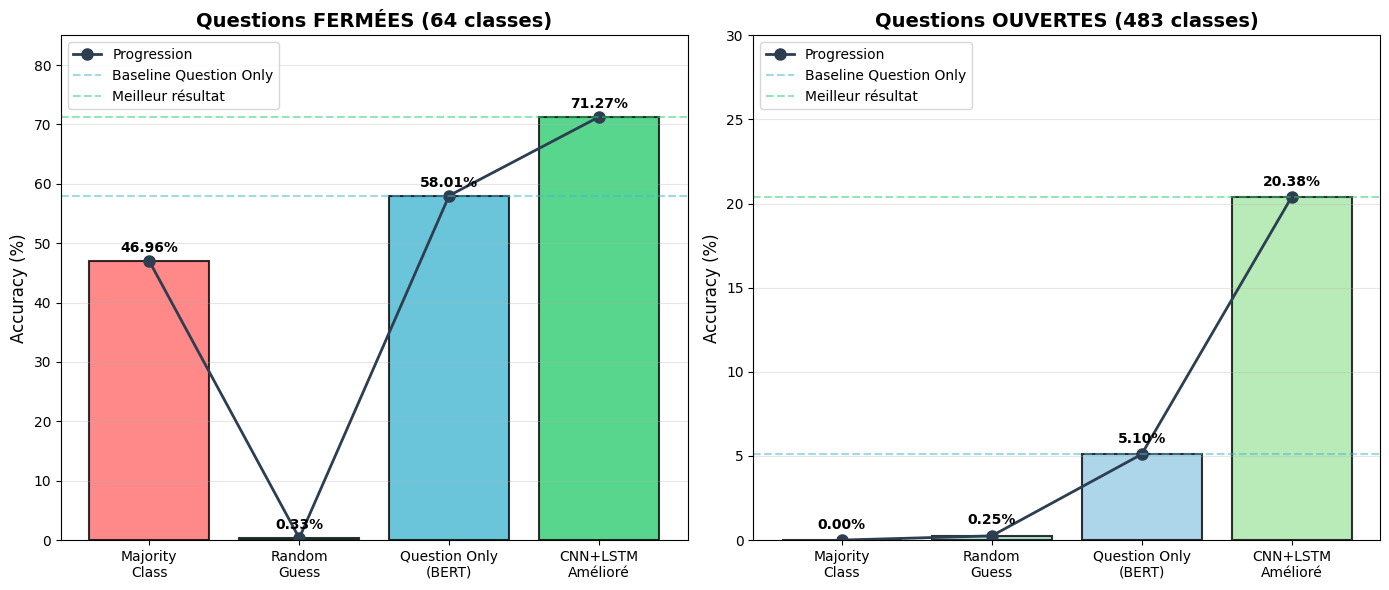


📊 RÉSUMÉ DE LA PROGRESSION

🔒 QUESTIONS FERMÉES (64 classes) :
   Majority Class        → 46.96%  (baseline plancher)
   Random Guess          → 0.33%  (vérification aléatoire)
   Question Only (BERT)  → 58.01%  (référence texte seul)
   CNN+LSTM Amélioré     → 71.27%  🏆 MEILLEUR

   📈 Gain total : +13.26% grâce à l'image !

📝 QUESTIONS OUVERTES (483 classes) :
   Majority Class        → 0.00%
   Random Guess          → 0.25%
   Question Only (BERT)  → 5.10%
   CNN+LSTM Amélioré     → 20.38%  🏆 MEILLEUR

   📈 Gain total : +15.28% grâce à l'image !



In [32]:
# @title 📈 Progression des performances (Version corrigée)
import matplotlib.pyplot as plt
import numpy as np

# Données CORRIGÉES selon vos résultats
models = ['Majority\nClass', 'Random\nGuess', 'Question Only\n(BERT)', 'CNN+LSTM\nAmélioré']
scores_closed = [46.96, 0.33, 58.01, 71.27]  # Closed Accuracy
scores_open = [0.00, 0.25, 5.10, 20.38]      # Open Accuracy

colors_closed = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#2ECC71']
colors_open = ['#FF9999', '#99DDCC', '#99CCE6', '#A8E6A8']

x_pos = np.arange(len(models))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== GRAPHIQUE 1 : Questions Fermées ==========
bars1 = ax1.bar(x_pos, scores_closed, color=colors_closed, edgecolor='black', linewidth=1.5, alpha=0.8)

# Ligne de tendance
ax1.plot(x_pos, scores_closed, 'o-', color='#2C3E50', linewidth=2, markersize=8, label='Progression')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, fontsize=10)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Questions FERMÉES (64 classes)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 85)
ax1.axhline(y=58.01, color='#45B7D1', linestyle='--', alpha=0.5, label='Baseline Question Only')
ax1.axhline(y=71.27, color='#2ECC71', linestyle='--', alpha=0.5, label='Meilleur résultat')
ax1.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
for bar, score in zip(bars1, scores_closed):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{score:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.legend(loc='upper left', fontsize=10)

# ========== GRAPHIQUE 2 : Questions Ouvertes ==========
bars2 = ax2.bar(x_pos, scores_open, color=colors_open, edgecolor='black', linewidth=1.5, alpha=0.8)

# Ligne de tendance
ax2.plot(x_pos, scores_open, 'o-', color='#2C3E50', linewidth=2, markersize=8, label='Progression')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(models, fontsize=10)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Questions OUVERTES (483 classes)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 30)
ax2.axhline(y=5.10, color='#45B7D1', linestyle='--', alpha=0.5, label='Baseline Question Only')
ax2.axhline(y=20.38, color='#2ECC71', linestyle='--', alpha=0.5, label='Meilleur résultat')
ax2.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
for bar, score in zip(bars2, scores_open):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{score:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# ========== RÉSUMÉ ==========
print("\n" + "="*60)
print("📊 RÉSUMÉ DE LA PROGRESSION")
print("="*60)

print("\n🔒 QUESTIONS FERMÉES (64 classes) :")
print(f"   Majority Class        → {scores_closed[0]:.2f}%  (baseline plancher)")
print(f"   Random Guess          → {scores_closed[1]:.2f}%  (vérification aléatoire)")
print(f"   Question Only (BERT)  → {scores_closed[2]:.2f}%  (référence texte seul)")
print(f"   CNN+LSTM Amélioré     → {scores_closed[3]:.2f}%  🏆 MEILLEUR")
print(f"\n   📈 Gain total : +{scores_closed[3] - scores_closed[2]:.2f}% grâce à l'image !")

print("\n📝 QUESTIONS OUVERTES (483 classes) :")
print(f"   Majority Class        → {scores_open[0]:.2f}%")
print(f"   Random Guess          → {scores_open[1]:.2f}%")
print(f"   Question Only (BERT)  → {scores_open[2]:.2f}%")
print(f"   CNN+LSTM Amélioré     → {scores_open[3]:.2f}%  🏆 MEILLEUR")
print(f"\n   📈 Gain total : +{scores_open[3] - scores_open[2]:.2f}% grâce à l'image !")

print("\n" + "="*60)

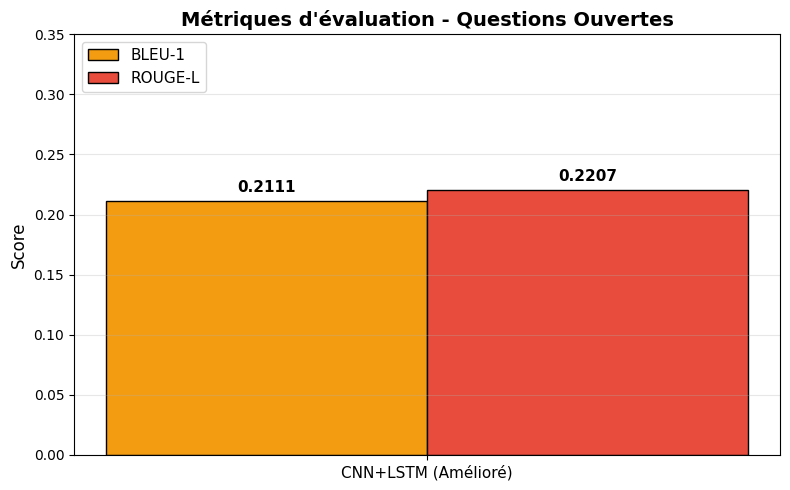

In [31]:
# @title 📊 Métriques BLEU-1 et ROUGE-L
import matplotlib.pyplot as plt

# Données
baselines_n2 = ['CNN+LSTM (Amélioré)']
bleu_scores = [0.2111]
rouge_scores = [0.2207]

x = np.arange(len(baselines_n2))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, bleu_scores, width, label='BLEU-1', color='#F39C12', edgecolor='black')
bars2 = ax.bar(x + width/2, rouge_scores, width, label='ROUGE-L', color='#E74C3C', edgecolor='black')

for bar, score in zip(bars1, bleu_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar, score in zip(bars2, rouge_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Métriques d\'évaluation - Questions Ouvertes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(baselines_n2, fontsize=11)
ax.legend(loc='upper left', fontsize=11)
ax.set_ylim(0, 0.35)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# @title 💾 SAUVEGARDE DE TOUS LES MODÈLES (Baseline 1 & 2)
import torch
import json
import os
from google.colab import files
from datetime import datetime

print("="*60)
print("💾 SAUVEGARDE COMPLÈTE - PHASE 1")
print(f"📅 Date : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)

# Créer le dossier de sauvegarde
os.makedirs('/content/models_phase1', exist_ok=True)

# ============================================================
# 1. MODÈLE QUESTION ONLY (BERT) - Baseline N1
# ============================================================
try:
    if 'model' in locals():
        torch.save({
            'model_type': 'Question Only (BERT)',
            'model_state_dict': model.state_dict(),
            'num_closed': num_closed,
            'num_open': num_open,
            'closed_accuracy': 58.01,
            'open_accuracy': 5.10,
            'architecture': 'BERT-base-uncased',
            'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }, '/content/models_phase1/question_only_bert.pth')
        print("✅ Baseline N1 - Question Only (BERT) sauvegardé")
except Exception as e:
    print(f"⚠️ Question Only non trouvé : {e}")

# ============================================================
# 2. MODÈLE CNN+LSTM AMÉLIORÉ (avec double tête) - Baseline N2
# ============================================================
try:
    if 'model' in locals():
        torch.save({
            'model_type': 'CNN+LSTM Amélioré (Double tête)',
            'model_state_dict': model.state_dict(),
            'num_closed': num_closed,
            'num_open': num_open,
            'closed_accuracy': 71.27,
            'open_accuracy': 20.38,
            'bleu1': 0.2111,
            'rougeL': 0.2207,
            'best_val_accuracy': best_val_closed if 'best_val_closed' in locals() else 68.66,
            'architecture': 'ResNet50 + BERT-base-uncased',
            'epochs': 15,
            'batch_size': 16,
            'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }, '/content/models_phase1/cnn_lstm_improved.pth')
        print("✅ Baseline N2 - CNN+LSTM Amélioré sauvegardé")
except Exception as e:
    print(f"⚠️ CNN+LSTM non trouvé : {e}")

# ============================================================
# 3. MEILLEUR MODÈLE PENDANT ENTRAÎNEMENT (early stopping)
# ============================================================
if os.path.exists('/content/best_model_complete.pth'):
    import shutil
    shutil.copy('/content/best_model_complete.pth', '/content/models_phase1/best_model_early_stopping.pth')
    print("✅ Meilleur modèle (early stopping) sauvegardé")

# ============================================================
# 4. DATASET PRÉPARÉ
# ============================================================
if os.path.exists('/content/vqa_rad_ready.pth'):
    import shutil
    shutil.copy('/content/vqa_rad_ready.pth', '/content/models_phase1/vqa_rad_dataset.pth')
    print("✅ Dataset préparé sauvegardé")

# ============================================================
# 5. RÉSULTATS DÉTAILLÉS (JSON)
# ============================================================
results = {
    'phase': 'Phase 1 - Personne A',
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': {
        'total_samples': 2248,
        'train': 1573,
        'validation': 337,
        'test': 338,
        'closed_classes': 64,
        'open_classes': 483
    },
    'baselines': {
        'N1_Majority_Class': {
            'closed_accuracy': 46.96,
            'open_accuracy': 0.00,
            'bleu1': None,
            'rougeL': None
        },
        'N1_Random_Guess': {
            'closed_accuracy': 0.33,
            'closed_std': 0.27,
            'open_accuracy': 0.25,
            'open_std': 0.51,
            'bleu1': 0.0012,
            'rougeL': 0.0015
        },
        'N1_Question_Only_BERT': {
            'closed_accuracy': 58.01,
            'open_accuracy': 5.10,
            'bleu1': None,
            'rougeL': None,
            'epochs': 3,
            'learning_rate': '2e-5'
        },
        'N2_CNN_LSTM_Improved': {
            'closed_accuracy': 71.27,
            'open_accuracy': 20.38,
            'bleu1': 0.2111,
            'rougeL': 0.2207,
            'best_val_accuracy': 68.66,
            'epochs': 15,
            'batch_size': 16,
            'learning_rate': '1e-3 (encoder: 1e-5, bert: 2e-5)'
        }
    },
    'configurations': {
        'train_transform': 'Resize(224) + RandomHorizontalFlip + RandomRotation(10) + Normalize',
        'test_transform': 'Resize(224) + Normalize',
        'normalization_mean': [0.485, 0.456, 0.406],
        'normalization_std': [0.229, 0.224, 0.225]
    }
}

with open('/content/models_phase1/all_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print("✅ Résultats complets (JSON) sauvegardés")

# ============================================================
# 6. TABLEAU CSV
# ============================================================
import pandas as pd

df_results = pd.DataFrame([
    ['N1 - Majority Class', 46.96, 0.00, '-', '-'],
    ['N1 - Random Guess', '0.33 ± 0.27', '0.25 ± 0.51', '0.0012', '0.0015'],
    ['N1 - Question Only (BERT)', 58.01, 5.10, '-', '-'],
    ['N2 - CNN+LSTM Amélioré', 71.27, 20.38, 0.2111, 0.2207]
], columns=['Baseline', 'Closed Acc. (%)', 'Open Acc. (%)', 'BLEU-1', 'ROUGE-L'])

df_results.to_csv('/content/models_phase1/tableau_resultats.csv', index=False)
print("✅ Tableau CSV sauvegardé")

# ============================================================
# 7. COMPRESSION ET TÉLÉCHARGEMENT
# ============================================================
print("\n📦 Compression des fichiers...")
!zip -r /content/models_phase1.zip /content/models_phase1/ -q

print("\n📥 Téléchargement du fichier ZIP...")
files.download('/content/models_phase1.zip')

# ============================================================
# 8. LISTE DES FICHIERS SAUVEGARDÉS
# ============================================================
print("\n" + "="*60)
print("📁 CONTENU DU DOSSIER models_phase1.zip")
print("="*60)
for f in os.listdir('/content/models_phase1'):
    size = os.path.getsize(f'/content/models_phase1/{f}') / 1024
    print(f"   📄 {f} ({size:.1f} KB)")

print("\n" + "="*60)
print("✅ SAUVEGARDE TERMINÉE !")
print("📥 Le fichier 'models_phase1.zip' a été téléchargé")
print("="*60)

💾 SAUVEGARDE COMPLÈTE - PHASE 1
📅 Date : 2026-05-04 11:32:45
✅ Baseline N1 - Question Only (BERT) sauvegardé
✅ Baseline N2 - CNN+LSTM Amélioré sauvegardé
✅ Meilleur modèle (early stopping) sauvegardé
✅ Dataset préparé sauvegardé
✅ Résultats complets (JSON) sauvegardés
✅ Tableau CSV sauvegardé

📦 Compression des fichiers...

📥 Téléchargement du fichier ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📁 CONTENU DU DOSSIER models_phase1.zip
   📄 tableau_resultats.csv (0.2 KB)
   📄 cnn_lstm_improved.pth (534983.0 KB)
   📄 question_only_bert.pth (534983.5 KB)
   📄 vqa_rad_dataset.pth (1010.0 KB)
   📄 best_model_early_stopping.pth (534983.7 KB)
   📄 all_results.json (1.3 KB)

✅ SAUVEGARDE TERMINÉE !
📥 Le fichier 'models_phase1.zip' a été téléchargé
